<a href="https://colab.research.google.com/github/thadduslee/Orbital-2026/blob/main/Base_file.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/thadduslee/Sentiment-Analysis-for-NUS-modules/blob/main/Sentiment_Analysis_for_NUS_modules.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
import pandas as pd
import numpy as np

### **Train sentiment analysis model**

In [2]:
data = pd.read_csv("/content/reviews.csv")
data = data.drop('Id', axis = 1)
vocab_size = 10000 #top 10k most frequent words
max_length = 1000 #max length of review, not the best for this dataset considering reviews are shorter but nusmods reviews or reddit reviews drag on to a few hundred words
embedding_dim = 64 #if we increase this, we better capture the nuance of every word
vectorize = tf.keras.layers.TextVectorization(
    max_tokens=vocab_size,
    standardize='lower_and_strip_punctuation', #clean text
    output_mode='int',
    output_sequence_length = max_length) #forces output to 1000

vectorize.adapt(data["Review"].astype(str)) #prevents crash if there are numbers in the dataset
model = tf.keras.models.Sequential([
    tf.keras.Input(shape=(1,), dtype=tf.string),
    vectorize,
    tf.keras.layers.Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        mask_zero=True),
    tf.keras.layers.LSTM(128, activation = "tanh"),
    tf.keras.layers.Dense(1, activation = "relu")
])

model.compile(loss = "mean_squared_error", optimizer = "adam", metrics = ["mean_absolute_error"]) #i treat this as a regression problem not a multi-class classification

data['Label'] = data['Label'].astype(int)
model.fit(data['Review'].astype(str).values, data["Label"], epochs = 3) #too many epochs and model memorizes data
model.save("sentiment_model.keras")


Epoch 1/3
3345/3345 ━━━━━━━━━━━━━━━━━━━━ 47s 13ms/step - loss: 0.6039 - mean_absolute_error: 0.4761
Epoch 2/3
3345/3345 ━━━━━━━━━━━━━━━━━━━━ 40s 12ms/step - loss: 0.3038 - mean_absolute_error: 0.3496
Epoch 3/3
3345/3345 ━━━━━━━━━━━━━━━━━━━━ 40s 12ms/step - loss: 0.2477 - mean_absolute_error: 0.3144


## **Step 1: Fetch ALL NUSMods data from Disqus (run once per session)**

This cell makes two API calls (threads + posts) and caches everything to disk.
Once it finishes, all later cells work purely from the in-memory `df_reviews` DataFrame.


In [3]:
import requests, json, csv, time, os, re
from bs4 import BeautifulSoup
import pandas as pd

def _get_api_key():
    try:
        from google.colab import userdata
        key = userdata.get("DISQUS_API_KEY")
        if key:
            print("API key loaded from Colab Secrets.")
            return key
    except Exception:
        pass
    key = os.environ.get("DISQUS_API_KEY", "")
    if key:
        print("API key loaded from environment variable.")
        return key
    raise RuntimeError(
        "No API key found.\n"
        "  In Colab: Secrets → add DISQUS_API_KEY → enable notebook access.\n"
        "  Make sure you copy the PUBLIC KEY from your Disqus app, not the Secret Key."
    )

DISQUS_API_KEY = _get_api_key()
FORUM_NAME     = "nusmods-prod"   # Disqus shortname for NUSMods
LIMIT          = 100         # Disqus max per request
DELAY          = 1.0         # Seconds between pages
JSON_OUT       = "nusmods_reviews.json"
CSV_OUT        = "nusmods_reviews.csv"
CHECKPOINT     = "nusmods_posts_checkpoint.json"


def verify_forum():
    resp = requests.get(
        "https://disqus.com/api/3.0/forums/details.json",
        params={"api_key": DISQUS_API_KEY, "forum": FORUM_NAME},
        timeout=15
    )
    data = resp.json()
    code = data.get("code", -1)

    # Disqus error codes: 2=missing key, 5=invalid key, 18=bad forum
    if code == 2 or code == 5:
        raise RuntimeError(
            f"\nAPI key rejected (Disqus code {code}).\n"
            "  Go to https://disqus.com/api/applications/ → your app\n"
            "  Copy the PUBLIC KEY (not Secret Key) and update your Colab Secret."
        )
    if code == 18:
        raise RuntimeError(
            f"\nForum not found (Disqus code {code}).\n"
            "  Check the shortname: open nusmods.com, right-click → View Page Source,\n"
            "  search for 'disqus_shortname' to find the correct value."
        )
    if code != 0:
        raise RuntimeError(f"Disqus error {code}: {data.get('response', data)}")

    info = data["response"]
    print(f"Forum verified: '{info['name']}' | shortname='{info['id']}' | posts={info.get('posts','?')}")
    return info


def fetch_all(endpoint, label, extra=None):
    """
    Downloads every page from a Disqus list endpoint.
    Returns a flat list of all items.
    """
    url   = f"https://disqus.com/api/3.0/{endpoint}"
    items = []
    cursor = None
    page   = 0

    print(f"\n⬇  Fetching {label}...")

    while True:
        params = {
            "api_key": DISQUS_API_KEY,
            "forum":   FORUM_NAME,
            "limit":   LIMIT,
            "order":   "asc",
        }
        if extra:
            params.update(extra)
        if cursor:
            params["cursor"] = cursor

        # Retry up to 5× on network errors or 429s
        for attempt in range(5):
            try:
                resp = requests.get(url, params=params, timeout=30)
            except requests.RequestException as e:
                wait = 2 ** attempt
                print(f"  Network error (attempt {attempt+1}): {e}. Retrying in {wait}s...")
                time.sleep(wait)
                continue

            if resp.status_code == 429:
                wait = int(resp.headers.get("Retry-After", 30))
                print(f"  Rate limited. Waiting {wait}s...")
                time.sleep(wait)
                continue

            if resp.status_code != 200:
                raise RuntimeError(f"HTTP {resp.status_code}: {resp.text[:300]}")

            break
        else:
            raise RuntimeError("Max retries exceeded — aborting.")

        body = resp.json()

        # Disqus surfaces API-level errors even on HTTP 200
        if body.get("code", 0) != 0:
            raise RuntimeError(f"Disqus error {body['code']}: {body.get('response')}")

        batch = body.get("response", [])
        items.extend(batch)
        page += 1
        print(f"  Page {page:>4}: +{len(batch):>4}  |  total {len(items):>6}", end="\r")

        cursor_data = body.get("cursor", {})
        if cursor_data.get("hasNext"):
            cursor = cursor_data["next"]
            time.sleep(DELAY)
        else:
            print(f" {label}: {len(items)} items fetched across {page} pages.")
            break

    return items


# clean HTML comment text
def clean_html(html_text):
    if not html_text:
        return ""
    text = BeautifulSoup(html_text, "html.parser").get_text(separator=" ")
    text = re.sub(r"Module review by.*?:", "", text)
    text = re.sub(r"Taken in AY\d+/\d+ Sem \d+", "", text)
    text = re.sub(r"Module review also posted here:.*", "", text)
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def module_code_from_title(title):
    """'CS1010 Programming Methodology'  →  'CS1010'"""
    if not title:
        return "UNKNOWN"
    first = title.strip().split()[0]
    return first if re.match(r"^[A-Z]{2,4}\d{4}[A-Z]?$", first) else "UNKNOWN"


print("=" * 60)
print(" NUSMods Disqus Scraper")
print("=" * 60)

verify_forum()

threads = fetch_all("forums/listThreads.json", "threads")

thread_map = {}
for t in threads:
    thread_map[t["id"]] = {
        "module_code":  module_code_from_title(t.get("title", "")),
        "module_title": t.get("title", "Unknown"),
        "module_link":  t.get("link", ""),
    }

known = sum(1 for v in thread_map.values() if v["module_code"] != "UNKNOWN")
print(f"  Thread map: {len(thread_map)} threads, {known} with valid module codes.")

raw_posts = fetch_all(
    "forums/listPosts.json",
    "posts",
    extra={"include": "approved"},
)

with open(CHECKPOINT, "w", encoding="utf-8") as f:
    json.dump(raw_posts, f)
print(f"  Checkpoint saved → {CHECKPOINT}")

records = []
for post in raw_posts:
    tid  = post.get("thread")
    info = thread_map.get(tid, {"module_code": "UNKNOWN",
                                "module_title": "Unknown",
                                "module_link":  ""})
    raw_msg = post.get("message", "") or ""
    records.append({
        "comment_id":       post.get("id"),
        "thread_id":        tid,
        "module_code":      info["module_code"],
        "module_title":     info["module_title"],
        "module_link":      info["module_link"],
        "author_name":      post.get("author", {}).get("name", "Anonymous"),
        "date":             post.get("createdAt"),
        "raw_message":      raw_msg,            # original HTML
        "message":          clean_html(raw_msg), # plain text
        "likes":            post.get("likes", 0),
        "dislikes":         post.get("dislikes", 0),
        "parent_comment_id": post.get("parent"),
    })


with open(JSON_OUT, "w", encoding="utf-8") as f:
    json.dump(records, f, indent=2, ensure_ascii=False)

if records:
    with open(CSV_OUT, "w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=records[0].keys())
        writer.writeheader()
        writer.writerows(records)

#load into pandas dataframe (easier manipulation)
df_reviews = pd.DataFrame(records)
df_reviews = df_reviews[
    (df_reviews["module_code"] != "UNKNOWN") &
    (df_reviews["message"].str.strip() != "")
].reset_index(drop=True)

print("\n" + "=" * 60)
print(f" Done. {len(df_reviews)} usable reviews across "
      f"{df_reviews['module_code'].nunique()} modules.")
print(f"    Saved → {JSON_OUT} | {CSV_OUT}")
print("=" * 60)
df_reviews[["module_code", "module_title", "date", "message"]].head(5)


API key loaded from Colab Secrets.
 NUSMods Disqus Scraper
Forum verified: 'NUSMods' | shortname='nusmods-prod' | posts=?

⬇  Fetching threads...
 threads: 20669 items fetched across 207 pages.
  Thread map: 20669 threads, 19013 with valid module codes.

⬇  Fetching posts...
 posts: 9624 items fetched across 97 pages.
  Checkpoint saved → nusmods_posts_checkpoint.json

 Done. 9538 usable reviews across 2072 modules.
    Saved → nusmods_reviews.json | nusmods_reviews.csv


,module_code,module_title,date,message
0,CS3216,CS3216 Software Development on Evolving Platforms,2014-06-29T23:43:01,Awesomeness!
1,CS1020E,CS1020E Data Structures and Algorithms I,2014-07-06T17:08:51,This looks interesting :). Anybody has any tip...
2,CS1020E,CS1020E Data Structures and Algorithms I,2014-07-06T19:07:57,"Hey Bhavesh, sure thing, you can find more inf..."
3,ACC1002X,ACC1002X Financial Accounting,2014-07-06T20:20:30,Definitely a course to take for people who wan...
4,CS3216,CS3216 Software Development on Evolving Platforms,2014-07-07T10:04:11,For those who are thinking of taking CS3216 in...


## **Step 2: Enter a module to analyse**

Filter from the already-loaded `df_reviews` DataFrame. No more file reads.


In [4]:
#show all available modules so the user knows what to type
available = sorted(df_reviews["module_code"].unique())
print(f"{len(available)} modules with reviews:")
print(", ".join(available))


2072 modules with reviews:
ACC1002, ACC1002X, ACC1006, ACC1701, ACC1701X, ACC2002, ACC2706, ACC2707, ACC2708, ACC2709, ACC3701, ACC3703, ACC3707, AH2101, AH2201, AH2202, AH2204, AH3203, AH3550, ALS1010, AN1101E, AN2101, AN2203, AN2205, AN3101, AR1101, BI3708A, BL5198, BL5217, BL5601, BL5602, BMA5334A, BMA5515, BMD5301, BMD5302, BMH5105, BMH5303, BMI5101, BMI5106, BMI5111, BMI5201, BMI5207, BMI5306, BMS5211, BN1112, BN2102, BN2201, BN2202, BN2204, BN2401, BN2403, BN4102, BN4301, BN4403, BN5101, BN5104, BN5210, BN6401, BPS5229, BSE3711, BSN3701, BSN3714, BSN4811, BSN4811A, BSP1004, BSP1005, BSP1702, BSP1703, BSP1707A, BSP2005, BSP3701A, BSP3701C, BT1101, BT2101, BT2102, BT2103, BT3017, BT3102, BT3103, BT4012, BT4013, BT4014, BT4016, BT4103, BT4211, BT4212, BT4221, BT4222, BT4240, BT4301, BT5153, CDE2000, CDE2001, CDE2212, CDE2310, CDE2501, CDE2502, CDE3504, CE1101, CE1103, CE2112T, CE2134, CE2155, CE2184, CE2407A, CE2407B, CE3115, CE3116, CE3121, CE3132, CE3155A, CE3155B, CE3165, CE3166,

### **Receive user input for module to conduct sentiment analysis on**

In [6]:
#module = input("Enter module code (e.g. CS1010A): ").upper().strip()
module = "MA1521"
subset = df_reviews[df_reviews["module_code"] == module]

if subset.empty:
    print(f"No reviews found for '{module}'.")
    close = [m for m in df_reviews['module_code'].unique() if m.startswith(module[:2])]
    if close:
        print(f"   Did you mean one of: {sorted(close)[:10]}?")
else:
    messages = subset["message"].tolist()
    print(f"Found {len(messages)} reviews for {module}.")


Found 102 reviews for MA1521.


### Helper function to clean **comments**

In [7]:
from bs4 import BeautifulSoup
import re

def clean_review_text(html_text):
    # parse HTML and separate tags with a space
    soup = BeautifulSoup(html_text, "html.parser")
    text = soup.get_text(separator=' ')

    # remove noise
    # remove "Module review by..." at the start
    text = re.sub(r'Module review by.*?:', '', text)
    # remove "Taken in AY..."
    text = re.sub(r'Taken in AY\d+/\d+ Sem \d+', '', text)
    # remove "Module review also posted here" footer
    text = re.sub(r'Module review also posted here:.*', '', text)

    # remove URLs
    text = re.sub(r'http\S+', '', text)

    # remove Newlines and extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    return text



### **Clean all the comments and store them in a new list variable**

In [8]:
# messages are already cleaned by clean_html() during scraping
clean_messages = messages
print(f"Using {len(clean_messages)} cleaned messages for {module}.")


Using 102 cleaned messages for MA1521.


### **Conduct sentiment analysis on all text data obtained and return overall sentiment regarding module**

In [9]:
count = 0
total = 0
for clean_message in clean_messages:
  total += model.predict(tf.constant([clean_message]))[0][0]
  count +=1
average = float(total/count)
average = round(average, 2)
if count < 5: #if number of reviews less than 5, sample size is too small (remember to change the training data for finetuning (comment for ethan))
  print(f"Not enough reviews to analyse sentiment for {module}")
elif average > 3.5:
  print(f"Overall sentiment of {module} is positive with a score of {average}/5")

elif average < 2.5:
  print(f"Overall sentiment of {module} is negative with a score of {average}/5")
else:
  print(f"Overall sentiment of {module} is neutral with a score of {average}/5")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━

##**Plotting the average sentiment of the module over time (arranged by academic year and semester)**


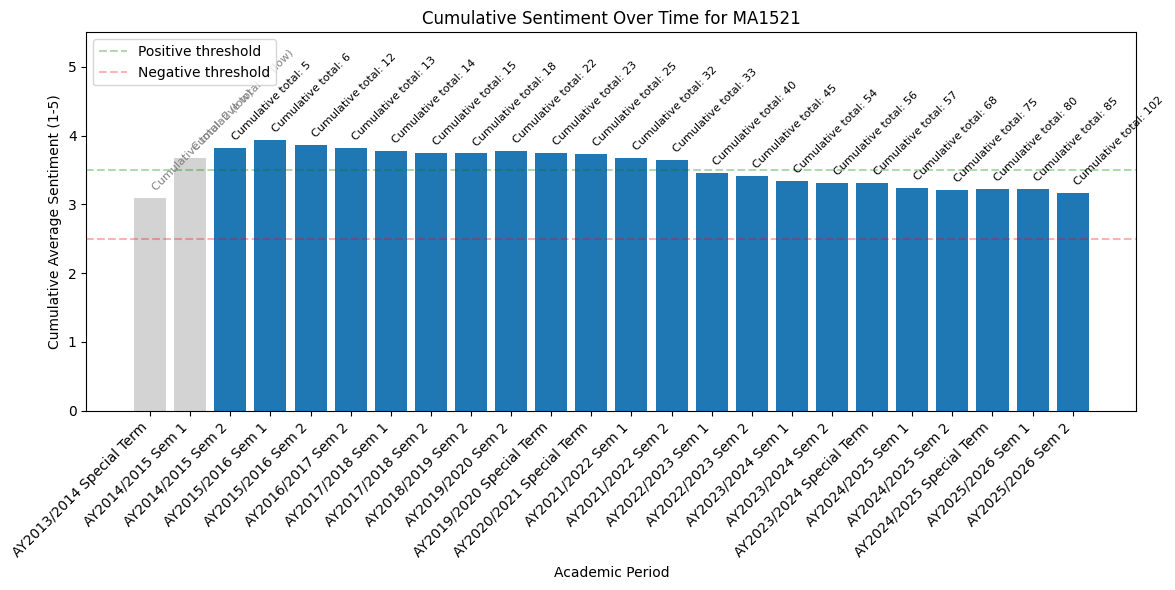

In [10]:
import matplotlib.pyplot as plt
import numpy as np

MIN_SAMPLES = 5 #remember that if number of comments below 5 we say insufficient reviews (comment for ethan)

def get_academic_period(date):
    month, year = date.month, date.year
    if month >= 8:
        return f"AY{year}/{year+1} Sem 1"
    elif month <= 5:
        return f"AY{year-1}/{year} Sem 2"
    else:
        return f"AY{year-1}/{year} Special Term"

def period_sort_key(period):
    term_order = {"Sem 1": 0, "Sem 2": 1, "Special Term": 2}
    ay_part, term = period.split(" ", 1)
    start_year = int(ay_part[2:6])
    return (start_year, term_order[term])

data_sorted = subset.copy()
data_sorted["date"] = pd.to_datetime(data_sorted["date"])
data_sorted = data_sorted.sort_values("date").reset_index(drop=True)
data_sorted["clean_message"] = data_sorted["message"].apply(clean_review_text)

if data_sorted.empty:
    print(f"No reviews found for {module}.")
else:
    all_scores = model.predict(
        tf.constant(data_sorted["clean_message"].tolist()),
        verbose=0
    ).flatten()
    data_sorted["sentiment_score"] = all_scores
    data_sorted["period"] = data_sorted["date"].apply(get_academic_period)

    # running cumulative count and mean, chronological order
    data_sorted["cum_n"]   = np.arange(1, len(data_sorted) + 1)
    data_sorted["cum_avg"] = data_sorted["sentiment_score"].expanding().mean()

    cum_summary = (
        data_sorted.groupby("period", sort=False)
        .agg(avg_sentiment=("cum_avg", "last"), n=("cum_n", "last"))
        .reset_index()
    )
    cum_summary["sort_key"] = cum_summary["period"].apply(period_sort_key)
    cum_summary = cum_summary.sort_values("sort_key").reset_index(drop=True)

    #code to plot the graph below (adjust if words overlap)
    colors = ["tab:blue" if n >= MIN_SAMPLES else "lightgray" for n in cum_summary["n"]]

    fig, ax1 = plt.subplots(figsize=(12, 6))
    bars = ax1.bar(cum_summary["period"], cum_summary["avg_sentiment"], color=colors)

    ax1.set_xlabel("Academic Period")
    ax1.set_ylabel("Cumulative Average Sentiment (1-5)")
    ax1.set_ylim(0, 5.5)
    ax1.axhline(y=3.5, color="green", linestyle="--", alpha=0.3, label="Positive threshold")
    ax1.axhline(y=2.5, color="red", linestyle="--", alpha=0.3, label="Negative threshold")

    for bar, n in zip(bars, cum_summary["n"]):
        label = f"Cumulative total: {n}" if n >= MIN_SAMPLES else f"Cumulative total: {n} (low)"
        ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.08,
                  label, ha="left", va="bottom", fontsize=8, rotation=45,
                  color="black" if n >= MIN_SAMPLES else "gray")

    plt.xticks(rotation=45, ha="right")
    plt.title(f"Cumulative Sentiment Over Time for {module}")
    ax1.legend(loc="upper left")
    plt.tight_layout()
    plt.show()

    current_total = cum_summary["n"].iloc[-1]
    if current_total < MIN_SAMPLES:
        print(f"Cumulative review count is still below {MIN_SAMPLES} "
              f"(currently {current_total}). Sentiment score not yet reliable.")

In [11]:
# Calculate the number of reviews per module
module_review_counts = df_reviews.groupby('module_code').size().reset_index(name='review_count')

# Filter for modules with less than 5 reviews
modules_with_low_reviews = module_review_counts[module_review_counts['review_count'] < 5]

# Get the total number of such modules
total_low_review_modules = len(modules_with_low_reviews)

# Get the total number of reviews in these modules
total_reviews_in_low_review_modules = modules_with_low_reviews['review_count'].sum()

print(f"Total number of modules with less than 5 reviews: {total_low_review_modules}")
print(f"Total number of reviews in these modules: {total_reviews_in_low_review_modules}")

# Optionally, display the list of these modules
# print("\nModules with less than 5 reviews:")
# display(modules_with_low_reviews)

Total number of modules with less than 5 reviews: 1565
Total number of reviews in these modules: 2696


In [12]:
df_reviews

,comment_id,thread_id,module_code,module_title,module_link,author_name,date,raw_message,message,likes,dislikes,parent_comment_id
0,1504826384,2874104237,CS3216,CS3216 Software Development on Evolving Platforms,http://nusmods.com/modules/CS3216/reviews,ahbengish,2014-06-29T23:43:01,<p>Awesomeness!</p>,Awesomeness!,2,0,NaN
1,1504826420,2874104284,CS1020E,CS1020E Data Structures and Algorithms I,http://nusmods.com/modules/CS1020E/reviews,Bhavesh .R,2014-07-06T17:08:51,<p>This looks interesting :). Anybody has any ...,This looks interesting :). Anybody has any tip...,0,0,NaN
2,1504826421,2874104284,CS1020E,CS1020E Data Structures and Algorithms I,http://nusmods.com/modules/CS1020E/reviews,Yangshun,2014-07-06T19:07:57,"<p>Hey Bhavesh, sure thing, you can find more ...","Hey Bhavesh, sure thing, you can find more inf...",0,0,NaN
3,1504826396,2874104252,ACC1002X,ACC1002X Financial Accounting,http://nusmods.com/modules/ACC1002X/reviews,Toh Weiqing,2014-07-06T20:20:30,<p>Definitely a course to take for people who ...,Definitely a course to take for people who wan...,1,0,NaN
4,1504826381,2874104237,CS3216,CS3216 Software Development on Evolving Platforms,http://nusmods.com/modules/CS3216/reviews,Yangshun,2014-07-07T10:04:11,<p>For those who are thinking of taking CS3216...,For those who are thinking of taking CS3216 in...,3,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
9533,6893695020,10573525861,GEN2009,GEN2009 Voices from the ground: stories & comm...,https://nusmods.com/courses/GEN2009/reviews,grapes are great,2026-06-26T03:52:01,<p>Taken in AY2526 Sem 2 under Dr. Azhar.</p><...,Taken in AY2526 Sem 2 under Dr. Azhar. orbigoo...,0,0,NaN
9534,6893695839,3884147861,LAS2201,LAS2201 Spanish 2,http://nusmods.com/modules/LAS2201/reviews,grapes are great,2026-06-26T03:57:20,"<p>Taken in AY2526 Sem 2, under Prof Sergio.</...","Taken in AY2526 Sem 2, under Prof Sergio. Prof...",1,0,NaN
9535,6893732319,2881825492,ST3236,ST3236 Stochastic Processes I,http://nusmods.com/modules/ST3236/reviews,algonerd,2026-06-26T07:56:54,"<p>Hi, I'm exchanger also and planning to take...","Hi, I'm exchanger also and planning to take th...",0,0,6.818958e+09
9536,6893760886,5929352290,IS3103,IS3103 Information Systems Leadership and Comm...,https://nusmods.com/modules/IS3103/reviews,orbigoodd,2026-06-26T10:19:17,"<p><a data-dsq-mention=""keithkgx:disqus"" href=...",keithkgx attendance is not tracked. there were...,0,0,6.892871e+09


In [13]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=df_reviews)

https://docs.google.com/spreadsheets/d/1Kci_DKxFeLMUySG8xObNEGfsL5wLiMGWixmTkMd4fww/edit#gid=0
